## MlipKit tutorial: MTP_model

This is a simple demo of usage of MlipKit with MTP (Moment Tensor Potential).

Along the demo we will:
1. Create and set the model
2. Train a low-parameters model
3. Compute properties of a structure with the model
4. Have a look at the hash-based security system
5. Load a pre-trained MTP model
6. Evaluate the model on its trainset



### 1. Create and set an MTP model
Let's have a look at the prototype of MTP_model class:

<img src="../MTP_model_prototype.png" />

We will need to pass the training hyperparameters. What are those? Let's find out:

```python
MTP_model.load_doc('hyperparameters')
```

In [2]:
from mlipkit.MTP.mtp_model import MTPModel
MTPModel.load_doc('hyperparameters')

mlip_bin: Path to the mlip-2 binary.

untrained_pot_file_dir: Directory with the untrained directory. It normally is `path/to/mlip-2/root/directory/untrained_mtps`.

mtp_level: MTP level; only even numbers from 2 to 28

min_dist: Minimum distance (in Angstrom) between two atoms to consider. I strongly suggest to determine it exactly (e.g. with mlipkit.mlip_models.utils.find_min_dist, or see parameter <up_mindist>).

max_dist: Maximum distance (in Angstrom) to consider for the radial functions.

radial_basis_type: Radial basis set. `RBChebyshev` is the most used one.

radial_basis_size: How many radial functions to use.

ene_weight: Weight for the energy in the fit. It will be normalized by the sum of weights of energy, forces and stress.

for_weight: Weight for the forces in the fit. It will be normalized by the sum of weights of energy, forces and stress.

str_weight: Weight for the stress tensor in the fit. It will be normalized by the sum of weights of energy, forces and stress.

sc

In [3]:
import numpy as np

from ase.io import read
from mlipkit.MTP.mtp_model import MTPModel
from mlipkit.utils import find_min_dist

root_dir = './'
name = 'MTP_trial_model' # custom name

train_set = read('../../../../../sets/Si/TrainSet.traj', index=':')

hyperparameters = dict(mlip_bin='/Users/samuel/Work/codes/mlip-2/build1/mlp',
                       untrained_pot_file_dir='/Users/samuel/Work/codes/mlip-2/untrained_mtps/',
                       mtp_level=6,
                       min_dist=find_min_dist(train_set),
                       max_dist=4,
                       radial_basis_type='RBChebyshev',
                       radial_basis_size='8',
                       bin_pref='mpirun -n 6')

new_model = MTPModel(root_dir,
                      name=name,
                      hyperparameters=hyperparameters,
                      train_set=train_set)



### 2. Train a low-parameters model
Our newly-created `new_model` has very low parameters (for time reasons). Let's train it.

If we hadn't already given the train set and the hyperparameters, we could pass them to the train_model() method.

In [4]:
new_model.train_model()

Training done successfully


True

### 3. Compute properties of a structure with the model
The training ran succesfully. Let's check if it's trained with
```python
new_model.is_trained
```

Note that the model was saved ad json in the root directory, and the trained potential is saved inside ```root_dir/trained_pot/```. Check
```pyhton
new_model.trained_pot_filepaths
```

Now let's use the trained potential to compute the properties of a structure.
But first let's have a look at the parameters needed:
```python
MTP_model.load_doc('parameters_compute_properties')
```


In [6]:
MTPModel.load_doc('parameters_compute_properties')

mlip_bin: Path to the mlip-2 binary.

bin_pref: Whatever to write before the binary path when launching mlip-2 (e.g. `mpirun`).



In [7]:

structures = read('../../../../../sets/Si/TestSet.traj', index=':1') # note this is a list
parameters = {'mlip_bin' : '/Users/samuel/Work/codes/mlip-2/build1/mlp',
              'bin_ref' : 'mpirun -n 6'}
results = new_model.compute_properties(structures, wdir='prediction', parameters=parameters)

# Let's print the energy
true_energy = structures[0].get_total_energy()
ml_energy = results[0].get_total_energy()

print(f'True energy: {true_energy} eV/atom;\nML energy: {ml_energy} eV/atom;\nError: {true_energy - ml_energy: .5e} eV/atom')

True energy: -24870.865413662847 eV/atom;
ML energy: -24870.607068714846 eV/atom;
Error: -2.58345e-01 eV/atom


### 4. Have a look at the hash-based security system
When a model is trained (successfully), two hashes are generated for the training set and the trained potential files. The hashes are stored in metadata and in the object itself. This allows to ensure, when opening a saved trained MlipModel object, that the training set is the one used for the training. It is always possible to ignore the metadata.

Let's load the model. Then we'll manually change the metadata and try to load the saved object again. 

In [8]:
from mlipkit.mlip_models import MlipModel

In [9]:
# First load the model
loaded_model = MlipModel.load_model(path ='MTP_trial_model.json', train_set=train_set)

# Let's try to compute some properties
results = loaded_model.compute_properties(structures, wdir='prediction', parameters=parameters)
print(f'ML energy: {results[0].get_total_energy()} eV/atom')

ML energy: -24870.607068714846 eV/atom


Now let's modify the hashes and reload

In [10]:
# Reload
loaded_model = MlipModel.load_model(path ='./MTP_trial_model.json')#, train_set=train_set)

# Let's try to compute some properties
results = loaded_model.compute_properties(structures, wdir='prediction', parameters=parameters)
print(f'ML energy: {results[0].get_total_energy()} eV/atom')

ML energy: -24870.607068714846 eV/atom


### 5. Load a pre-trained MTP model
In case we already had a trained model, we can load it as an MlipModel (sub)class, provided that we have all the files needed to define a trained potential of its class. Let's use ```MTP_model.load_doc('trained_pot_files')``` to see what these files are. Then we'll build a dictionary with the paths.

In [12]:
MTPModel.load_doc('trained_pot_files')

potential_file: pot.mtp - Output file .mtp; it is the only file needed.



In [13]:
files = {'potential_file' : '../../../../../sets/Si/pot.mtp'}
pre_trained_model = MTPModel(root_dir='pre_trained_model', 
                              name='pre_trained', 
                              pre_trained=True, 
                              pre_trained_pot_filepaths=files)

Let's use it to compute some properties

In [14]:
results = pre_trained_model.compute_properties(structures, wdir='prediction', parameters=parameters)
true_energy = structures[0].get_total_energy()
ml_energy = results[0].get_total_energy()
print(f'True energy: {true_energy} eV/atom;\nML energy: {ml_energy} eV/atom;\nError: {true_energy - ml_energy: .5e} eV/atom')

True energy: -24870.865413662847 eV/atom;
ML energy: -24870.829873487684 eV/atom;
Error: -3.55402e-02 eV/atom


### 6. Evaluate the model on the training set and test set
Now let's compute error metrics for the pre-trained model on the datasets. 

In [15]:
# Load the test set
test_set = read('../../../../../sets/Si/TestSet.traj', index=':')

# Evaluate on training set
res_train_set, errs_train = pre_trained_model.evaluate_on_dataset(dataset=train_set, wdir='evaluation-train', parameters=parameters, save_results=True)

# Evaluate on test set
res_test_set, errs_test = pre_trained_model.evaluate_on_dataset(dataset=test_set, wdir='evaluation-test', parameters=parameters, save_results=True)

printing in /Users/samuel/Work/codes/python_packages/mlipkit/mlipkit/tutorial/MTP/Tutorial_1/evaluation-train/Energy_comparison.dat
printing in /Users/samuel/Work/codes/python_packages/mlipkit/mlipkit/tutorial/MTP/Tutorial_1/evaluation-train/Forces_comparison.dat
printing in /Users/samuel/Work/codes/python_packages/mlipkit/mlipkit/tutorial/MTP/Tutorial_1/evaluation-train/Stress_comparison.dat
printing in /Users/samuel/Work/codes/python_packages/mlipkit/mlipkit/tutorial/MTP/Tutorial_1/evaluation-test/Energy_comparison.dat
printing in /Users/samuel/Work/codes/python_packages/mlipkit/mlipkit/tutorial/MTP/Tutorial_1/evaluation-test/Forces_comparison.dat
printing in /Users/samuel/Work/codes/python_packages/mlipkit/mlipkit/tutorial/MTP/Tutorial_1/evaluation-test/Stress_comparison.dat


<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:21: SyntaxWarning: invalid escape sequence '\m'
<>:22: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:21: SyntaxWarning: invalid escape sequence '\m'
<>:22: SyntaxWarning: invalid escape sequence '\m'
/var/folders/qk/jf9cpj2s2n5_vwcl0wm9q6mr0000gn/T/ipykernel_32533/2453367094.py:9: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('True Forces (eV/$\mathrm{\AA}$)')
/var/folders/qk/jf9cpj2s2n5_vwcl0wm9q6mr0000gn/T/ipykernel_32533/2453367094.py:10: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('ML Forces (eV/$\mathrm{\AA}$)')
/var/folders/qk/jf9cpj2s2n5_vwcl0wm9q6mr0000gn/T/ipykernel_32533/2453367094.py:21: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('True Forces (eV/$\mathrm{\AA}$)')
/var/folders/qk/jf9cpj2s2n5_vwcl0wm9q6mr0000gn/T/ipykernel_32533/2453367

Text(-5.47015575272185, 3.1770931870522103, 'rmse: 3.36541e-04 eV/Ang\nmae: 2.52966e-04 eV/Ang\nR2: 9.99977e-01')

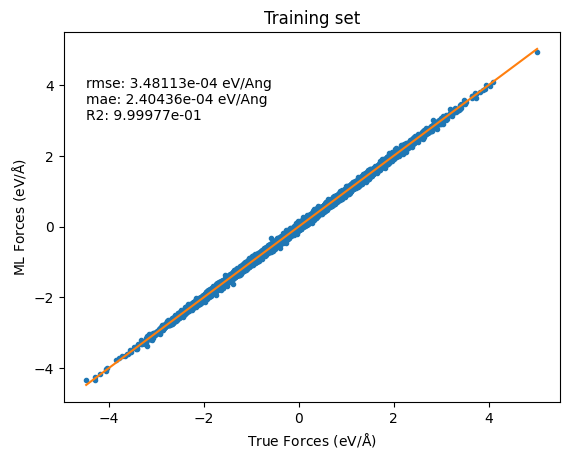

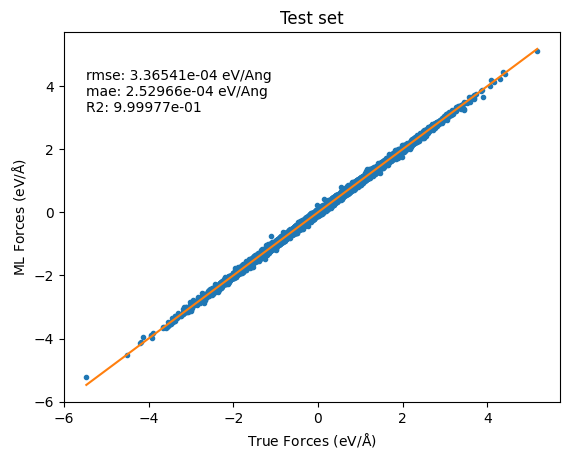

In [16]:
# Let's plot the comparisons
from matplotlib import pyplot as plt

# For training set
true_forces = np.array([x.get_forces() for x in train_set]).flatten()
ml_forces = np.array([x.get_forces() for x in res_train_set]).flatten()

plt.plot(true_forces, ml_forces, '.')
plt.xlabel('True Forces (eV/$\mathrm{\AA}$)')
plt.ylabel('ML Forces (eV/$\mathrm{\AA}$)')
plt.plot([min(true_forces), max(true_forces)], [min(true_forces), max(true_forces)])
plt.title('Training set')
plt.text(x=min(true_forces), y=max(true_forces)-2, s=f"rmse: {errs_train['energy'][0]:.5e} eV/Ang\nmae: {errs_train['energy'][1]:.5e} eV/Ang\nR2: {errs_train['energy'][2]:.5e}")

# For test set
true_forces = np.array([x.get_forces() for x in test_set]).flatten()
ml_forces = np.array([x.get_forces() for x in res_test_set]).flatten()

plt.figure()
plt.plot(true_forces, ml_forces, '.')
plt.xlabel('True Forces (eV/$\mathrm{\AA}$)')
plt.ylabel('ML Forces (eV/$\mathrm{\AA}$)')
plt.plot([min(true_forces), max(true_forces)], [min(true_forces), max(true_forces)])
plt.title('Test set')
plt.text(x=min(true_forces), y=max(true_forces)-2, s=f"rmse: {errs_test['energy'][0]:.5e} eV/Ang\nmae: {errs_test['energy'][1]:.5e} eV/Ang\nR2: {errs_test['energy'][2]:.5e}")


